### Plot median-UMAP from 30 PC of SNV-polymorphism at homozygous and heterozygous sites

In [61]:
from dynamicviz import boot
from pathlib import Path
import pandas as pd
import random
import os

# Import data
work_dir = Path("/home/b05b01002/HDD/project_scRNAed")
cell_cluster = pd.read_csv(work_dir / "references/ptr_tenx_batch1_rs17_curated.csv", index_col=0)
cell_cluster["Barcode"] = cell_cluster.index
palette = {
    3: "#E28413",
    4: "#F3EC5B",
    8: "#FF8F8F",
    6: "#6362A7",
    5: "#61C9A8",
    2: "#7A4A33",
    1: "#1F77B4",
    7: "#FF0000",
    9: "whitesmoke",
    10: "whitesmoke",
    11: "whitesmoke"
}
pca_projection_het = pd.read_csv(work_dir / "outputs/notebooks/UMAP-show-scSNV/pca_projection_het_loci.csv", index_col=0) 
pca_projection_hom = pd.read_csv(work_dir / "outputs/notebooks/UMAP-show-scSNV/pca_projection_homo_loci.csv", index_col=0) 
pca_projection_all = pd.read_csv(work_dir / "outputs/notebooks/UMAP-show-scSNV/pca_projection_all_loci.csv", index_col=0)

# Output path
path_out = work_dir / "outputs/notebooks/DynamicViz/"
os.makedirs(path_out, exist_ok=True)

# DynamicViz params
B = 10
RANDOM_SEED = 42

# UMAP params
n_neighbors = 15
min_dist = 0.1
metric = "euclidean"

Define plotting function

In [3]:
import matplotlib.pyplot as plt
import numpy as np

def rotate_points(x, y, angle_deg):
    """Rotate (x, y) by angle_deg counterclockwise."""
    angle_rad = np.deg2rad(angle_deg)
    x_rot = x * np.cos(angle_rad) - y * np.sin(angle_rad)
    y_rot = x * np.sin(angle_rad) + y * np.cos(angle_rad)
    return x_rot, y_rot

def plot_umap_scatter(
        df, x="UMAP-1", y="UMAP-2", color_col=None, palette=None,  rotate=0,
        output_path="umap.svg", width=4.1, height=3.2, dot_size=2,
    ):
    if palette is None:
        palette = DEFAULT_PALETTE

    fig, ax = plt.subplots(figsize=(width, height))

    # get colors
    if color_col:
        colors = df[color_col].map(palette).fillna("#D4D4D4").values
    else:
        colors = "#D4D4D4"

    # rotate points if needed
    if rotate != 0:
        x_vals, y_vals = rotate_points(df[x], df[y], rotate)
    else:
        x_vals, y_vals = df[x], df[y]
        
    # plot
    ax.scatter(
        x_vals,
        y_vals,
        c=colors,
        s=dot_size,
        edgecolor="none"
    )

    # cosmetic adjustments
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_facecolor("white")
    fig.patch.set_facecolor("white")

    # save to SVG
    plt.savefig(output_path, format="svg", bbox_inches="tight", pad_inches=0)


### Run DynamicViz

In [62]:
pca_projection = {
    "het": pca_projection_het,
    "hom": pca_projection_hom,
    "all": pca_projection_all
}

In [83]:
site = "hom" # Change to "hom", "het" or "all" as needed
cells_to_keep = pca_projection[site].index.intersection(cell_cluster.index)
X = pca_projection[site].loc[cells_to_keep].to_numpy()
Y = cell_cluster.loc[cells_to_keep]

Run DynamicViz

In [84]:
datetime = pd.Timestamp.now().strftime("%Y%m%d_%H%M%S")
out = boot.generate(
    X,
    method="umap",
    Y=Y,
    B=B,
    no_bootstrap=True,
    num_jobs=min(50, B),
    save=path_out / f"dynamicviz_{site}_{datetime}.csv",
    use_n_pcs=False,
    subsample=False,
    return_times=False,
    **{
        "n_neighbors": n_neighbors,
        "min_dist": min_dist,
        "metric": metric,
    }
)

100%|██████████| 10/10 [00:00<00:00, 8036.60it/s]


Get median coordinate

In [85]:
median_umap = out.groupby("Barcode").median()

Plot median UMAP

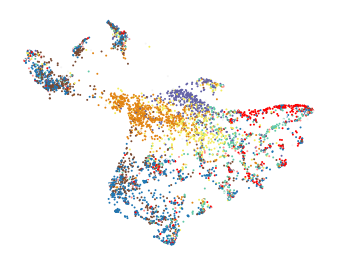

In [86]:
plot_umap_scatter(
    median_umap,
    x="x1",
    y="x2",
    color_col="Cluster",
    palette=palette,
    output_path=path_out / f"median_umap_{site}_{datetime}.svg",
    rotate=0,
    dot_size=2
)